## Crop Yield Prediction  

**Importing libraries**

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split,GroupKFold,cross_val_score
from sklearn.ensemble import (RandomForestRegressor,
                              ExtraTreesRegressor,
                              GradientBoostingRegressor,
                              HistGradientBoostingRegressor)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score,mean_absolute_error

### Import dataset

In [93]:
os.getcwd()

'c:\\Users\\levie\\Desktop\\Desktop\\CMU\\Academic Bootcamp\\YieldSense-Crop-Yield-Forecasting-Carnegie-Mellon-University\\data\\raw'

In [118]:
crop = pd.read_csv("updated_crop_prediction_gee_computations.csv")
print(crop.head())

      GNDVI      NDVI      NDWI      SAVI crop_type date_of_image field_id  \
0  0.084801  0.060190 -0.084801  0.090280      Rice    01-01-2023  Field_1   
1  0.222009  0.213957 -0.222009  0.320896      Rice    16-01-2023  Field_1   
2  0.431204  0.403306 -0.431204  0.604837      Rice    31-01-2023  Field_1   
3  0.444132  0.418187 -0.444132  0.627144      Rice    15-02-2023  Field_1   
4  0.387985  0.375138 -0.387985  0.562591      Rice    03-02-2023  Field_1   

   gee_gndvi  gee_ndvi  gee_ndwi  gee_rainfall  gee_savi   gee_temp  latitude  \
0   0.295214  0.330551 -0.295214      1.261195  0.176135  19.472947  22.62523   
1   0.426134  0.410556 -0.426134      2.446377  0.197592  19.497637  22.62523   
2   0.406732  0.399812 -0.406732      3.722453  0.201092  21.559492  22.62523   
3   0.426134  0.410556 -0.426134      2.314044  0.197592  19.230342  22.62523   
4   0.426134  0.410556 -0.426134      1.325544  0.197592  18.863504  22.62523   

   longitude   rainfall  soil_moisture  temp

### Selecting required columns

In [119]:
crop_gee = crop.drop(["gee_gndvi","gee_ndvi","gee_ndwi","gee_savi","field_id","gee_rainfall","gee_temp"], axis = 1)
crop_gee.head()

,GNDVI,NDVI,NDWI,SAVI,crop_type,date_of_image,latitude,longitude,rainfall,soil_moisture,temperature,yield
0,0.084801,0.060190,-0.084801,0.090280,Rice,01-01-2023,22.62523,88.497924,1.662354,46.119353,9.884229,40.218031
1,0.222009,0.213957,-0.222009,0.320896,Rice,16-01-2023,22.62523,88.497924,8.446302,37.542525,13.967073,30.870338
2,0.431204,0.403306,-0.431204,0.604837,Rice,31-01-2023,22.62523,88.497924,3.862833,24.926279,13.590147,45.330050
3,0.444132,0.418187,-0.444132,0.627144,Rice,15-02-2023,22.62523,88.497924,16.623542,24.114157,12.343355,49.711781
4,0.387985,0.375138,-0.387985,0.562591,Rice,03-02-2023,22.62523,88.497924,9.496210,27.420927,11.007707,34.542646


In [120]:
#Checking the shape of the dataset
print(crop_gee.shape)

(1625, 12)


In [121]:
crop_gee.info()

<class 'pandas.DataFrame'>
RangeIndex: 1625 entries, 0 to 1624
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   GNDVI          1625 non-null   float64
 1   NDVI           1625 non-null   float64
 2   NDWI           1625 non-null   float64
 3   SAVI           1625 non-null   float64
 4   crop_type      1625 non-null   str    
 5   date_of_image  1625 non-null   str    
 6   latitude       1625 non-null   float64
 7   longitude      1625 non-null   float64
 8   rainfall       1625 non-null   float64
 9   soil_moisture  1625 non-null   float64
 10  temperature    1625 non-null   float64
 11  yield          1625 non-null   float64
dtypes: float64(10), str(2)
memory usage: 152.5 KB


In [122]:
#Checking for null values
print(crop_gee.isnull().sum())

GNDVI            0
NDVI             0
NDWI             0
SAVI             0
crop_type        0
date_of_image    0
latitude         0
longitude        0
rainfall         0
soil_moisture    0
temperature      0
yield            0
dtype: int64


In [123]:
# Sorting dataset according to date
# Convert the date strings to Python dates row by row
crop_gee['date_of_image'] = pd.to_datetime(
    crop_gee['date_of_image'], format='%d-%m-%Y', errors='coerce'
)

# Split date into year, month, and day columns
crop_gee['year'] = crop_gee['date_of_image'].dt.year
crop_gee['month'] = crop_gee['date_of_image'].dt.month
crop_gee['day'] = crop_gee['date_of_image'].dt.day

# Add a simple season signal from the month of the image
season_map = {
    12: 'winter', 1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'autumn', 10: 'autumn', 11: 'autumn'
}
crop_gee['season'] = crop_gee['month'].map(season_map)

print(crop_gee[['date_of_image', 'year', 'month', 'day', 'season']].head())

  date_of_image  year  month  day  season
0    2023-01-01  2023      1    1  winter
1    2023-01-16  2023      1   16  winter
2    2023-01-31  2023      1   31  winter
3    2023-02-15  2023      2   15  winter
4    2023-02-03  2023      2    3  winter


In [124]:
#Sorting the dataset by date
crop_gee.sort_values(by='date_of_image', inplace= True)

In [ ]:
'''
# Fill missing rainfall and temperature using the median for each location,
# then fall back to the dataset median for any location with no valid values.
loc_rain_median = crop_gee.groupby(['longitude', 'latitude'])['gee_rainfall'].transform('median')
loc_temp_median = crop_gee.groupby(['longitude', 'latitude'])['gee_temp'].transform('median')

crop_gee['gee_rainfall'] = crop_gee['gee_rainfall'].fillna(loc_rain_median)
crop_gee['gee_temp'] = crop_gee['gee_temp'].fillna(loc_temp_median)

crop_gee['gee_rainfall'] = crop_gee['gee_rainfall'].fillna(crop_gee['gee_rainfall'].median())
crop_gee['gee_temp'] = crop_gee['gee_temp'].fillna(crop_gee['gee_temp'].median())

print(f"Missing values after location-based median fill:\n{crop_gee[['gee_rainfall', 'gee_temp']].isnull().sum()}")

# Optional: save the location medians for reference
spatial_medians = (
    crop_gee.groupby(['longitude', 'latitude'], as_index=False)[['gee_rainfall', 'gee_temp']]
    .median()
    .rename(columns={
        'gee_rainfall': 'median_rainfall_by_location',
        'gee_temp': 'median_temp_by_location'
    })
)

print(spatial_medians.head())
print(crop_gee.isnull().sum())
'''

Missing values after location-based median fill:
gee_rainfall    0
gee_temp        0
dtype: int64
   longitude   latitude  median_rainfall_by_location  median_temp_by_location
0  73.083890  22.126898                     0.009680                20.968874
1  73.098048  22.227830                     0.062549                20.873298
2  73.177157  22.257184                     0.051797                20.737870
3  73.234528  22.343941                     0.071886                20.737870
4  73.246857  22.450656                     0.051447                20.518312
crop_type        0
date_of_image    0
gee_gndvi        0
gee_ndvi         0
gee_ndwi         0
gee_rainfall     0
gee_savi         0
gee_temp         0
latitude         0
longitude        0
soil_moisture    0
yield            0
year             0
month            0
day              0
season           0
dtype: int64


In [125]:
#Checking for duplicates
print(crop_gee.duplicated().sum())

0


### Exploratory Data Analysis

In [126]:
sns.set_style("whitegrid")

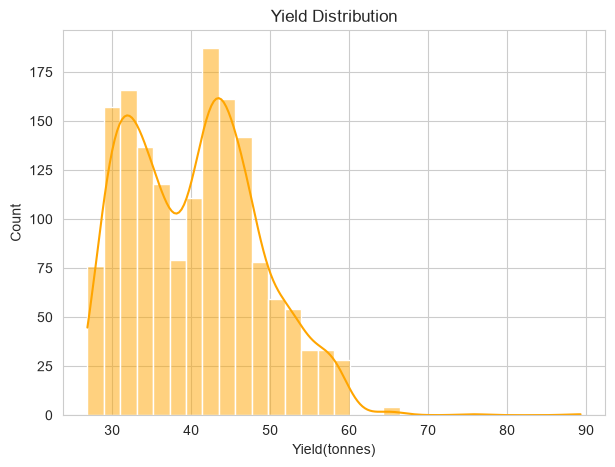

In [127]:
plt.figure(figsize = (7,5))
sns.histplot(crop_gee["yield"], bins= 30, kde = True, color= "orange")
plt.xlabel("Yield(tonnes)")
plt.title("Yield Distribution")
plt.show()

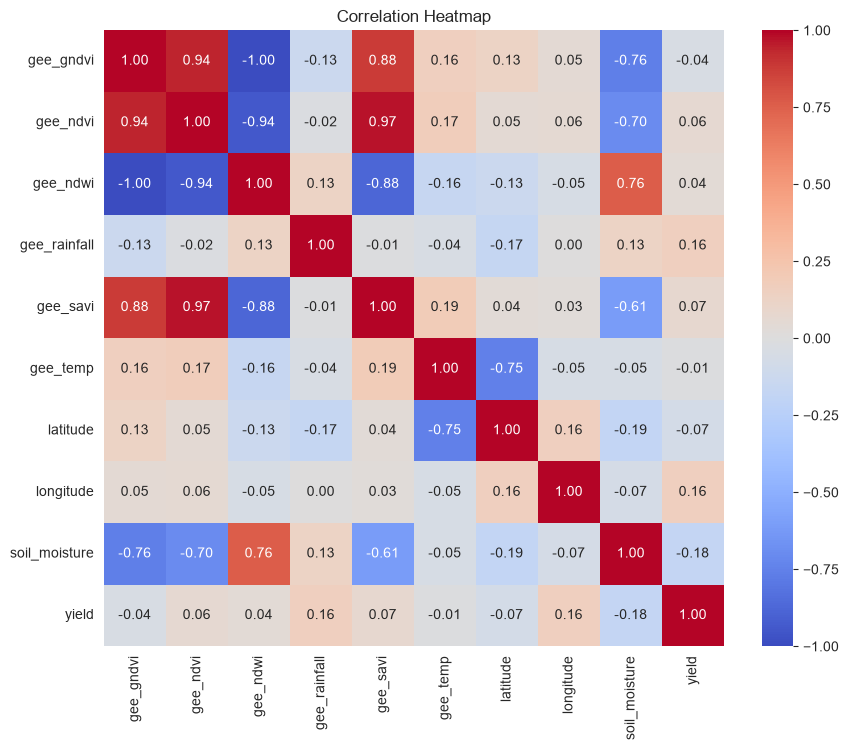

In [105]:
plt.figure(figsize= (10,8))

corr_matrix = crop_gee.select_dtypes(include = ["float64"]).corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

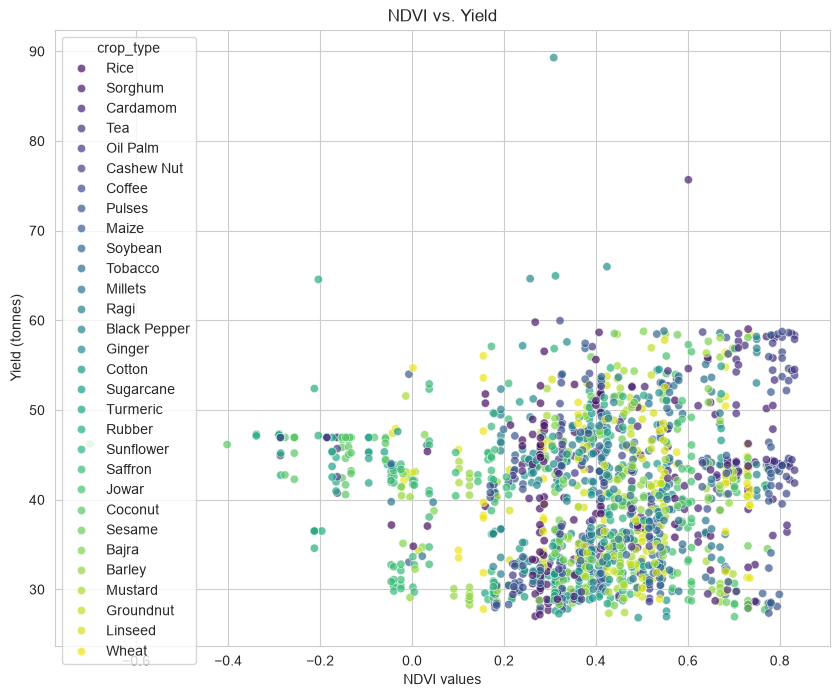

In [106]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=crop_gee, x="gee_ndvi", y="yield", hue="crop_type", palette="viridis", alpha=0.7)
plt.xlabel("NDVI values")
plt.ylabel("Yield (tonnes)")
plt.title("NDVI vs. Yield")
plt.show()

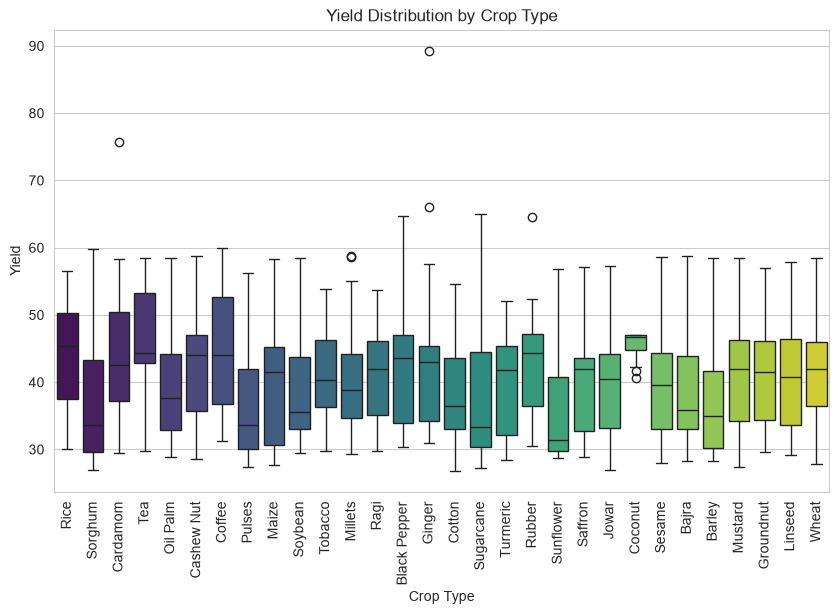

In [107]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=crop_gee, x="crop_type", y="yield", hue= "crop_type", palette="viridis")
plt.xlabel("Crop Type")
plt.ylabel("Yield")
plt.title("Yield Distribution by Crop Type")
plt.xticks(rotation=90)
plt.show()

In [133]:
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

Outliers detected in yield: 3
Outliers detected in NDVI: 33
Outliers detected in GNDVI: 104
Outliers detected in NDWI: 104
Outliers detected in SAVI: 33
Outliers detected in soil_moisture: 89
Outliers detected in temperature: 0
Outliers detected in rainfall: 15


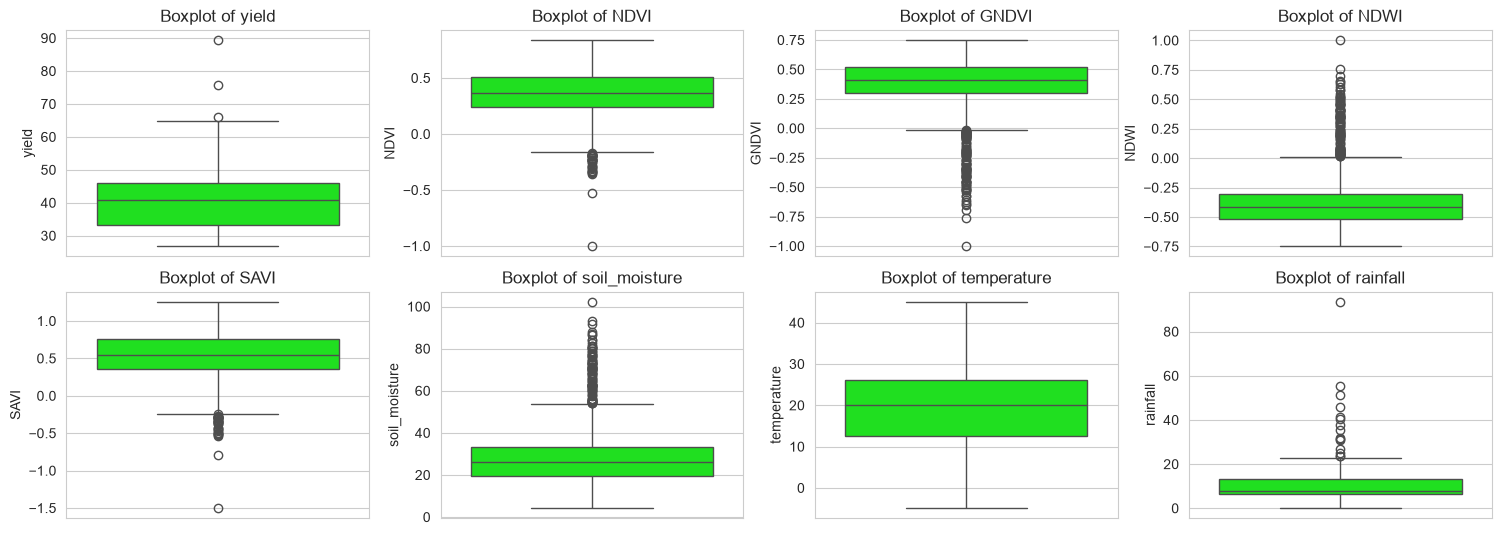

In [134]:
plt.figure(figsize=(15,8))

for i,col in enumerate (["yield", "NDVI", "GNDVI","NDWI", "SAVI", "soil_moisture", "temperature", "rainfall"]):
    
    outliers = detect_outliers(crop_gee, col)
    print(f"Outliers detected in {col}: {len(outliers)}")
    
    plt.subplot(3,4,i+1)    
    sns.boxplot(y=crop_gee[col],color='lime')
    plt.title(f"Boxplot of {col}")
    plt.xlabel('')
    plt.ylabel(col)    

plt.tight_layout()
plt.show()

In [135]:
# Handle Outliers
# IQR Method to identify and cap Outliers
def cap_outliers(data,column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)


for col in ["yield", "NDVI", "GNDVI", "NDWI", "SAVI", "soil_moisture", "temperature", "rainfall"]:
    cap_outliers(crop_gee, col) 

Outliers detected in yield: 0
Outliers detected in NDVI: 0
Outliers detected in GNDVI: 0
Outliers detected in NDWI: 0
Outliers detected in SAVI: 0
Outliers detected in soil_moisture: 0
Outliers detected in temperature: 0
Outliers detected in rainfall: 0


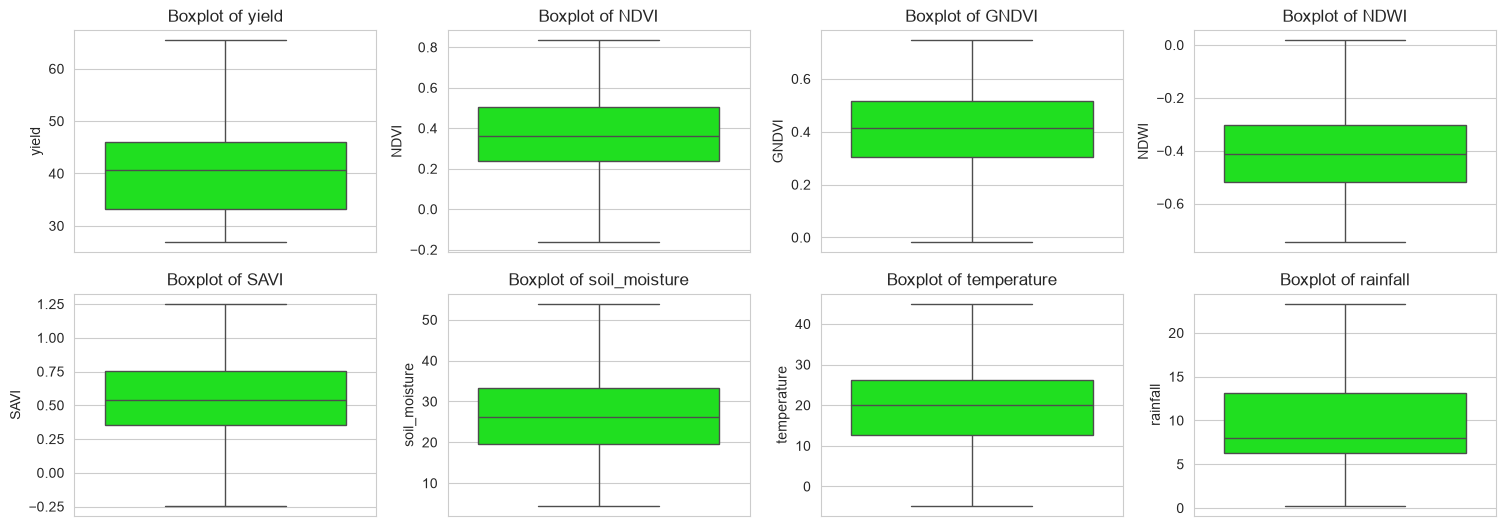

In [136]:
plt.figure(figsize=(15,8))

for i,col in enumerate (["yield", "NDVI", "GNDVI","NDWI", "SAVI", "soil_moisture", "temperature", "rainfall"]):
    
    outliers = detect_outliers(crop_gee, col)
    print(f"Outliers detected in {col}: {len(outliers)}")
    
    plt.subplot(3,4,i+1)    
    sns.boxplot(y=crop_gee[col],color='lime')
    plt.title(f"Boxplot of {col}")
    plt.xlabel('')
    plt.ylabel(col)    

plt.tight_layout()
plt.show()

### Preparing data for model training

In [137]:
crop_gee.head()

,GNDVI,NDVI,NDWI,SAVI,crop_type,date_of_image,latitude,longitude,rainfall,soil_moisture,temperature,yield,year,month,day,season
0,0.084801,0.060190,-0.084801,0.090280,Rice,2023-01-01,22.625230,88.497924,1.662354,46.119353,9.884229,40.218031,2023,1,1,winter
884,0.684082,0.746464,-0.684082,1.119561,Sorghum,2023-01-01,23.333139,77.204198,9.295824,8.508628,6.183541,44.192887,2023,1,1,winter
1067,0.724448,0.815642,-0.724448,1.223265,Cardamom,2023-01-01,11.204696,76.728898,9.818897,5.740849,18.063898,44.046829,2023,1,1,winter
495,0.587380,0.663035,-0.587380,0.994412,Tea,2023-01-01,11.297044,76.821134,8.777456,14.298677,18.586950,42.481925,2023,1,1,winter
866,0.364336,0.336426,-0.364336,0.504603,Sorghum,2023-01-01,13.643129,77.799626,6.383177,29.023912,19.322451,33.363751,2023,1,1,winter


In [140]:
# Split data to features and targets
X = crop_gee.drop(columns=["date_of_image", "yield"])
y = crop_gee["yield"]

# Group by location so nearby points do not leak between train and validation
group = crop_gee["longitude"].round(3).astype(str) + "_" + crop_gee["latitude"].round(3).astype(str)

# Categorical and numeric columns
cat_cols = ["crop_type", "season"]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

models = {
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(random_state=42, n_estimators=500),
    "ExtraTrees": ExtraTreesRegressor(random_state=42, n_estimators=500),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "HistGBM": HistGradientBoostingRegressor(random_state=42)
}

from joblib import dump
from pathlib import Path

registry_dir = Path("../model_registry")
registry_dir.mkdir(exist_ok=True)

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    cv = GroupKFold(n_splits=5)
    r2_scores = cross_val_score(pipe, X, y, cv=cv, groups=group, scoring="r2")
    rmse_scores = -cross_val_score(pipe, X, y, cv=cv, groups=group, scoring="neg_root_mean_squared_error")

    print(f"{name}: mean R2 = {r2_scores.mean():.4f}, std = {r2_scores.std():.4f}")
    print(f"{name}: mean RMSE = {rmse_scores.mean():.4f}, std = {rmse_scores.std():.4f}")

    model_path = registry_dir / f"{name.lower()}_model.joblib"
    dump(pipe, model_path)
    print(f"Saved model to: {model_path}")

Ridge: mean R2 = 0.6960, std = 0.0666
Ridge: mean RMSE = 4.3950, std = 0.3785
Saved model to: ..\model_registry\ridge_model.joblib
RandomForest: mean R2 = 0.9364, std = 0.0087
RandomForest: mean RMSE = 2.0277, std = 0.1834
Saved model to: ..\model_registry\randomforest_model.joblib
ExtraTrees: mean R2 = 0.9386, std = 0.0061
ExtraTrees: mean RMSE = 1.9955, std = 0.1692
Saved model to: ..\model_registry\extratrees_model.joblib
GradientBoosting: mean R2 = 0.9314, std = 0.0125
GradientBoosting: mean RMSE = 2.1049, std = 0.2519
Saved model to: ..\model_registry\gradientboosting_model.joblib
HistGBM: mean R2 = 0.9353, std = 0.0117
HistGBM: mean RMSE = 2.0431, std = 0.2378
Saved model to: ..\model_registry\histgbm_model.joblib


### **Model Summary**
>This notebook compares five regression models for crop yield prediction: Ridge, RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, and HistGradientBoostingRegressor.

The models were improved using grouped cross-validation by location, one-hot encoding for categorical variables, feature engineering from date, different seasons, location-based median imputation for missing rainfall and temperature, and outlier clipping.

Model performance was evaluated using R² and RMSE to compare predictive accuracy fairly across different algorithms.